# تصنيف الأخبار العربية
## Arabic News Classification: Sports  | Politics ️ | Economy
**NLP  Project**
**Categories:** رياضة (Sports) | سياسة (Politics) | اقتصاد (Economy)
---

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Arabic text processing
import pyarabic.araby as araby

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Font support for Arabic in plots
matplotlib.rcParams['axes.unicode_minus'] = True


[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1006)>


## 📊 2. Dataset

We create a labeled Arabic news dataset with **3 categories**:
- **رياضة** (Sports) ⚽
- **سياسة** (Politics) 🏛️
- **اقتصاد** (Economy) 💰

> **Note:** You can replace this with a real dataset from Kaggle (e.g., SANAD Arabic News Dataset, KALIMAT, etc.)

In [50]:
# ============================================================
# ARABIC NEWS DATASET  (120+ samples, 40+ per category)
# ============================================================

sports_news = [
    "فاز المنتخب الوطني بكأس العالم لكرة القدم بعد مباراة مثيرة",
    "سجل اللاعب هدفاً رائعاً في الدقيقة الأخيرة من المباراة",
    "أعلن النادي عن التعاقد مع مدرب جديد للفريق الأول",
    "أقيمت بطولة العرب لكرة السلة في العاصمة الرياضية",
    "تأهل الفريق إلى نهائي دوري أبطال آسيا بعد فوزه ذهاباً وإياباً",
    "انتهت المباراة بالتعادل الإيجابي بهدفين لكل فريق",
    "أحرز الرياضي الميدالية الذهبية في بطولة العالم لألعاب القوى",
    "جرى السحب على قرعة كأس الملك في مقر الاتحاد",
    "أعلن الملاكم تقاعده عن المنافسات الدولية بعد مسيرة حافلة",
    "اختتمت بطولة التنس الكبرى بفوز المصنف الأول عالمياً",
    "أصيب النجم بكسر في ساقه وسيغيب عن الملاعب ثلاثة أشهر",
    "يستضيف الملعب الوطني مباريات كأس القارات الصيف المقبل",
    "أعلنت الفيفا عن التقنيات الجديدة لتحكيم مباريات كرة القدم",
    "حصل السباح العربي على الرقم القياسي في بطولة الألعاب الآسيوية",
    "جاء دور المجموعات في كأس العالم بنتائج مثيرة للجدل",
    "أعلن الاتحاد الدولي لكرة اليد عن استضافة البطولة العالمية",
    "قدم المدرب الوطني استقالته عقب الخسارة الثقيلة أمام المنافس",
    "وقع النادي على عقد رعاية ضخم مع شركة دولية كبرى",
    "بلغ عدد مشجعي المنتخب في الملعب أكثر من ثمانين ألف متفرج",
    "حقق الفارس الميدالية البرونزية في بطولة الفروسية العالمية",
    "استقطبت بطولة الغولف الدولية أبرز لاعبي العالم في الإمارات",
    "أنهى الدراج العربي السباق في المركز الثالث على مستوى القارة",
    "وقع الحكم تحت طائلة العقوبة بسبب خطأ فادح في الوقت الإضافي",
    "تصدر المنتخب مجموعته في التصفيات الأولمبية بفارق الأهداف",
    "نظم الاتحاد العربي للسباحة بطولة ناجحة شارك فيها اثنا عشر بلداً",
    "عاد النجم إلى التدريبات بعد غياب طويل بسبب الإصابة",
    "أعلن البطل العالمي ترشحه للانتخابات الأولمبية المقبلة",
    "تنافس الرياضيون العرب في عشرين رياضة ضمن الألعاب الإقليمية",
    "احتفل الجمهور بفوز المنتخب في ساحة الاحتفالات الكبرى",
    "استقطب نهائي دوري أبطال أوروبا اهتماماً عربياً واسعاً",
    "أكد المدرب أن الفريق سيلعب بخطة هجومية في المباراة القادمة",
    "حصل الملعب الجديد على شهادة الاستدامة البيئية الدولية",
    "فازت الأمازون السعودية ببطولة الدوري لأول مرة في تاريخها",
    "شارك أكثر من ألف رياضي في دورة الألعاب الخليجية الشبابية",
    "أعلنت لجنة أولمبية عن دعمها لرياضيين من ذوي الإعاقة",
    "انتهى الشوط الأول بتقدم الفريق المضيف بهدف نظيف",
    "رصد المراقبون مستوى متردياً في أداء الدوري هذا الموسم",
    "أهدى الفريق الكأس لمشجعيه بعد مسيرة طويلة من الانتظار",
    "أكد اللاعب أنه سيكمل مسيرته مع النادي حتى نهاية العقد",
    "خسر الفريق القومي اللقب في الرمية الأخيرة من المباراة النهائية"
]

politics_news = [
    "أجرت الحكومة محادثات دبلوماسية مع الدول المجاورة لتعزيز الاستقرار",
    "أصدر البرلمان قانوناً جديداً لتنظيم الانتخابات المحلية",
    "أعلن الرئيس عن خطة إصلاحية شاملة تهدف إلى تطوير المنظومة الإدارية",
    "عقد مجلس الوزراء اجتماعاً طارئاً لمناقشة التطورات الأمنية",
    "وقّعت الدولتان اتفاقية تعاون مشترك في عدة مجالات حيوية",
    "أكد وزير الخارجية التزام البلاد بالمبادرات الإقليمية للسلام",
    "جرت الانتخابات البرلمانية في أجواء ديمقراطية وشفافة",
    "طالبت المعارضة بفتح تحقيق برلماني في قضايا الفساد الإداري",
    "زار وفد دبلوماسي رفيع المستوى عدة عواصم عربية وأوروبية",
    "أطلقت الحكومة مبادرة وطنية لمكافحة الفساد وتعزيز الشفافية",
    "ناقش القادة الإقليميون الأزمة الإنسانية في القمة الطارئة",
    "أعلنت الأمم المتحدة دعمها لمسار الحل السياسي في المنطقة",
    "وافق البرلمان على ميزانية الدولة للسنة المالية القادمة",
    "أعادت الدولتان علاقاتهما الدبلوماسية بعد سنوات من القطيعة",
    "انتهت القمة العربية ببيان مشترك يدعو إلى وقف إطلاق النار",
    "أعلن الحزب الحاكم عن برنامجه الانتخابي للدورة المقبلة",
    "طالب المجتمع الدولي بتطبيق قرارات مجلس الأمن في المنطقة",
    "عقد زعماء الدول الكبرى مؤتمراً لمناقشة التوترات الدولية",
    "استقال وزير الداخلية إثر أحداث أمنية خطيرة في البلاد",
    "أكد رئيس الوزراء أن الحكومة ستمضي قدماً في خطط الإصلاح",
    "اجتمع وزراء الخارجية العرب لبحث الأوضاع الإقليمية المتوترة",
    "حصل حزب المعارضة على أغلبية المقاعد في الانتخابات التشريعية",
    "أطلق الرئيس حواراً وطنياً شاملاً لتوحيد الصفوف الداخلية",
    "انتقدت منظمات حقوق الإنسان سياسات الاعتقال التعسفي",
    "وافقت الحكومة على مشروع قانون يكفل حرية الصحافة والإعلام",
    "طالب المواطنون بإجراء إصلاحات سياسية في مسيرات سلمية حاشدة",
    "أعلنت اللجنة العليا للانتخابات عن موعد الاستفتاء الدستوري",
    "اتفق الطرفان على خارطة طريق للحوار السياسي المباشر",
    "ناقش مجلس الشيوخ مشروع قانون جديد لمكافحة الإرهاب",
    "شارك المسؤول في مفاوضات السلام على هامش الجمعية العامة للأمم المتحدة",
    "دعا المبعوث الأممي الأطراف المتنازعة إلى طاولة الحوار",
    "صادق مجلس النواب على اتفاقية دولية تتعلق بحقوق الإنسان",
    "أكدت الحكومة تمسكها بمبدأ السيادة الوطنية في مواجهة الضغوط",
    "أصدرت المحكمة الدستورية حكماً بعدم دستورية بعض بنود القانون",
    "يبدأ البرلمان الأسبوع المقبل مناقشة الإصلاحات الانتخابية المقترحة",
    "أعلن المسؤول عزمه الترشح للرئاسة في الانتخابات المقبلة",
    "أشادت الدول الكبرى بمسار الإصلاح الديمقراطي في البلاد",
    "أعلنت وزارة العدل إطلاق حزمة من الإصلاحات القضائية الشاملة",
    "وُجِّهت اتهامات لمسؤول حكومي رفيع بتهمة استغلال النفوذ",
    "أكدت الحكومة التزامها الكامل بالمعاهدات والاتفاقيات الدولية"
]

economy_news = [
    "ارتفعت أسعار النفط إلى أعلى مستوياتها منذ ثلاث سنوات",
    "أعلن البنك المركزي عن خفض أسعار الفائدة لتحفيز النمو",
    "نما الناتج المحلي الإجمالي بنسبة خمسة بالمئة في الربع الأخير",
    "أعلنت الشركة الكبرى عن توسعات ضخمة في أسواق الشرق الأوسط",
    "انخفضت البورصة بسبب مخاوف التضخم والبيانات الاقتصادية الضعيفة",
    "أطلقت الحكومة صندوق استثمار لدعم المشاريع الصغيرة والمتوسطة",
    "ارتفع معدل التضخم إلى ثمانية بالمئة وسط ضغوط معيشية متزايدة",
    "وقّعت الدولتان اتفاقية تجارة حرة ستفيد آلاف الشركات المحلية",
    "رفعت وكالة التصنيف الدولية تصنيف الدولة الائتماني درجة كاملة",
    "أعلن وزير المالية عن خفض العجز في الميزانية العامة للدولة",
    "استقطب المعرض الاقتصادي الدولي آلاف المستثمرين من كل أنحاء العالم",
    "بلغت الصادرات الوطنية رقماً قياسياً خلال النصف الأول من العام",
    "أعلنت مجموعة شركات كبرى توفير عشرة آلاف فرصة عمل جديدة",
    "أطلقت المصارف الرائدة خدمات التمويل الرقمي لدعم الاقتصاد المحلي",
    "انخفض سعر صرف العملة بسبب الضغوط الاقتصادية العالمية المتزايدة",
    "أعلنت الحكومة عن حزمة إنقاذ اقتصادي للقطاعات الأكثر تضرراً",
    "تصدرت الدولة قائمة الاقتصادات الأسرع نمواً في المنطقة العربية",
    "ارتفعت أسهم قطاع التكنولوجيا بشكل ملحوظ في البورصة الوطنية",
    "أعلن صندوق النقد الدولي عن توقعات إيجابية للاقتصاد المحلي",
    "وصل حجم الاستثمارات الأجنبية المباشرة إلى مستوى غير مسبوق",
    "أقرت الحكومة إصلاحات ضريبية لتشجيع بيئة الأعمال وجذب المستثمرين",
    "انطلقت شركة ناشئة بتمويل عربي في قطاع الذكاء الاصطناعي والبيانات",
    "اتسعت الفجوة بين الطبقات الاجتماعية وسط تراجع اقتصادي ملموس",
    "أصدرت وزارة التجارة حزمة تسهيلات لدعم تصدير المنتجات المحلية",
    "وقّع الاتحاد الأوروبي وعدة دول عربية اتفاقية تعاون اقتصادي مشترك",
    "سجلت السوق العقارية نمواً استثنائياً في المدن الكبرى بنسبة عشرين بالمئة",
    "بلغ حجم تداولات البورصة أعلى مستوياته في تاريخ السوق المالية",
    "أطلقت وزارة الاقتصاد خطة تحفيزية لدعم رواد الأعمال الشباب",
    "انخفضت البطالة إلى أدنى معدلاتها خلال عقد من الزمن",
    "استقطبت الدولة مؤتمر قمة الأعمال الدولي بمشاركة كبرى الشركات العالمية",
    "أعلن البنك الدولي عن دعم مالي لمشاريع البنية التحتية في المنطقة",
    "رصد التقرير السنوي تراجعاً في الإنتاج الصناعي خلال الأشهر الأخيرة",
    "تشهد أسواق العملات تذبذباً حاداً بسبب قرارات المصارف المركزية",
    "أعلنت الشركة العملاقة دخولها السوق العربي باستثمارات بمليارات الدولارات",
    "طُرح نقاش واسع حول آليات تنويع مصادر الدخل الوطني في القمة الاقتصادية",
    "أطلقت وزارة الصناعة حزمة دعم للقطاع التصنيعي المتضرر من الأزمات",
    "وصل الدين العام لمستوى أثار قلق المحللين والمؤسسات المالية الدولية",
    "اتجهت الدول نحو تخفيض الاعتماد على النفط ودعم الطاقة المتجددة",
    "فازت شركة محلية بعقد ضخم لتطوير بنية تحتية بمليار دولار",
    "أعلن وزير التخطيط عن مؤشرات إيجابية تؤكد تعافي الاقتصاد الوطني"
]

texts  = sports_news + politics_news + economy_news
labels = (['رياضة'] * len(sports_news) +
          ['سياسة'] * len(politics_news) +
          ['اقتصاد'] * len(economy_news))

df = pd.DataFrame({'text': texts, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

csv_path = 'arabic_news.csv'
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
# Read DataFrame back from the CSV file as the dataset source
df = pd.read_csv(csv_path, encoding='utf-8-sig')

print('\n Class distribution:')
print(df['label'].value_counts())
df.head(8)


 Class distribution:
label
سياسة     40
رياضة     40
اقتصاد    40
Name: count, dtype: int64


,text,label
0,وقّعت الدولتان اتفاقية تعاون مشترك في عدة مجال...,سياسة
1,طالبت المعارضة بفتح تحقيق برلماني في قضايا الف...,سياسة
2,تأهل الفريق إلى نهائي دوري أبطال آسيا بعد فوزه...,رياضة
3,أعلن الحزب الحاكم عن برنامجه الانتخابي للدورة ...,سياسة
4,أعلن البطل العالمي ترشحه للانتخابات الأولمبية ...,رياضة
5,وافقت الحكومة على مشروع قانون يكفل حرية الصحاف...,سياسة
6,أصدرت المحكمة الدستورية حكماً بعدم دستورية بعض...,سياسة
7,أصيب النجم بكسر في ساقه وسيغيب عن الملاعب ثلاث...,رياضة


## 📌 Optional: Load from a CSV File (Kaggle Dataset)
If you have a real dataset (e.g., SANAD), uncomment and use:

In [51]:
# # Option A: Load from CSV
# df = pd.read_csv('arabic_news.csv')
# df = df[['text', 'label']]  # make sure columns are named 'text' and 'label'

# # Keep only our 3 categories
# target_labels = ['رياضة', 'سياسة', 'اقتصاد']
# df = df[df['label'].isin(target_labels)].reset_index(drop=True)
# print(df['label'].value_counts())
# print(f'Total samples: {len(df)}')

##2 . Arabic Text Preprocessing

Steps applied:
1. **Lowercasing** (remove diacritics/tashkeel)
2. **Remove punctuation & special characters**
3. **Tokenization**
4. **Stop-word removal**
5. **Stemming / Light Stemming**

In [52]:
# ──────────────────────────────────────────────────────────
#  Arabic Stop Words
# ──────────────────────────────────────────────────────────
ARABIC_STOPWORDS = set([
    'في','من','إلى','على','عن','مع','بعد','قبل','حتى','إذا','لكن',
    'كان','كانت','يكون','تكون','هو','هي','هم','هن','أنا','نحن',
    'أنت','أنتم','هذا','هذه','ذلك','تلك','التي','الذي','الذين',
    'اللاتي','اللواتي','ما','لا','لم','لن','ليس','قد','سوف',
    'أو','و','ف','ب','ل','ك','لل','ال','والتي','والذي','وقد',
    'وكان','أن','إن','لأن','منذ','خلال','حول','بين','ضد','عند',
    'عبر','نحو','دون','كل','بعض','غير','أكثر','أقل','جميع','بشكل',
    'حيث','كما','بما','فيما','وفق','وفقا','إلا','أيضا','فقط','هنا',
    'هناك','الآن','أمس','اليوم','عام','عاما','سنة','أشهر','شهر'
])


def remove_diacritics(text):
    """Remove Arabic diacritics (tashkeel)."""
    return araby.strip_tashkeel(text)


def normalize_arabic(text):
    """Normalize Arabic characters (alef forms, taa marbouta, etc.)."""
    text = re.sub('[إأآا]', 'ا', text)   # normalize alef
    text = re.sub('ة', 'ه', text)        # taa marbouta → haa
    text = re.sub('ى', 'ي', text)        # alef maqsura → yaa
    return text


def remove_noise(text):
    """Remove punctuation, URLs, numbers, and non-Arabic characters."""
    text = re.sub(r'http\S+|www.\S+', '', text)      # URLs
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)  # keep Arabic only
    #https://stackoverflow.com/questions/12518689/regular-expression-not-to-allow-numbers-just-arabic-letters

    text = re.sub(r'\s+', ' ', text).strip()
    return text


def light_stem(word):
    """Simple Arabic light stemmer: removes common prefixes/suffixes."""
    #https://acit2k.org/ACIT/images/stories/year2014/month1/ACIT2017_Proceeding/167.pdf
    prefixes = ['مست','است','ال','وال','بال','فال','كال','لل','ب','و','ف','ل','س','ي','ت','ن','أ']
    suffixes = ['ات','ون','ين','ان','تم','كم','هم','ها','ني','تي','كن','هن','ية','وا']
    for p in sorted(prefixes, key=len, reverse=True):
        if word.startswith(p) and len(word) - len(p) >= 3:
            word = word[len(p):]; break
    for s in sorted(suffixes, key=len, reverse=True):
        if word.endswith(s) and len(word) - len(s) >= 3:
            word = word[:-len(s)]; break
    return word


def preprocess_arabic(text, stem=True):
    """Full preprocessing pipeline for Arabic text."""
    text = remove_diacritics(text)       # Step 1: Remove tashkeel
    text = normalize_arabic(text)        # Step 2: Normalize characters
    text = remove_noise(text)            # Step 3: Remove noise
    tokens = text.split()                # Step 4: Tokenize (whitespace)
    tokens = [t for t in tokens          # Step 5: Remove stop words
              if t not in ARABIC_STOPWORDS and len(t) >= 2]
    if stem:                             # Step 6: Light stemming
        tokens = [light_stem(t) for t in tokens]
    return ' '.join(tokens)

df['processed_text'] = df['text'].apply(preprocess_arabic)

print(' Sample comparison:')
for i in [0, 41, 82]:
    print(f"\n[{df['label'][i]}]")
    print(f"  Original : {df['text'][i]}")
    print(f"  Processed: {df['processed_text'][i]}")

 Sample comparison:

[سياسة]
  Original : وقّعت الدولتان اتفاقية تعاون مشترك في عدة مجالات حيوية
  Processed: قعت دولت اتفاقيه عاون مشترك عده مجال حيويه

[رياضة]
  Original : عاد النجم إلى التدريبات بعد غياب طويل بسبب الإصابة
  Processed: عاد نجم الي تدريب غياب طويل سبب اصابه

[اقتصاد]
  Original : وصل الدين العام لمستوى أثار قلق المحللين والمؤسسات المالية الدولية
  Processed: وصل دين عام مستوي اثار قلق محلل مؤسس ماليه دوليه


##  5. Feature Extraction

Three methods:
- **Bag of Words (BoW)**
- **TF-IDF**

In [53]:

X = df['processed_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
# ── Bag of Words ──────────────────────────────────────────
bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

# ── TF-IDF ────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

## 6. Model Training & Evaluation

Models used:
1. **Logistic Regression**
2. **Support Vector Machine (LinearSVC)**
3. **Naive Bayes**
4. **Random Forest**

In [55]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM (LinearSVC)'    : LinearSVC(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

# Feature sets
feature_sets = {
    'BoW'   : (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

results = []

print('Training all model/feature combinations...\n')
print(f"{'Model':<25} {'Features':<10} {'Accuracy':>10}")
print('-' * 48)

for feat_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)
        acc = accuracy_score(y_test, preds)
        results.append({
            'Model'   : model_name,
            'Features': feat_name,
            'Accuracy': acc,
            'Preds'   : preds
        })
        print(f'{model_name:<25} {feat_name:<10} {acc:>10.4f}')



Training all model/feature combinations...

Model                     Features     Accuracy
------------------------------------------------
Logistic Regression       BoW            0.7917
SVM (LinearSVC)           BoW            0.8333
Naive Bayes               BoW            0.7917
Random Forest             BoW            0.6250
Logistic Regression       TF-IDF         0.7917
SVM (LinearSVC)           TF-IDF         0.7917
Naive Bayes               TF-IDF         0.7917
Random Forest             TF-IDF         0.6250


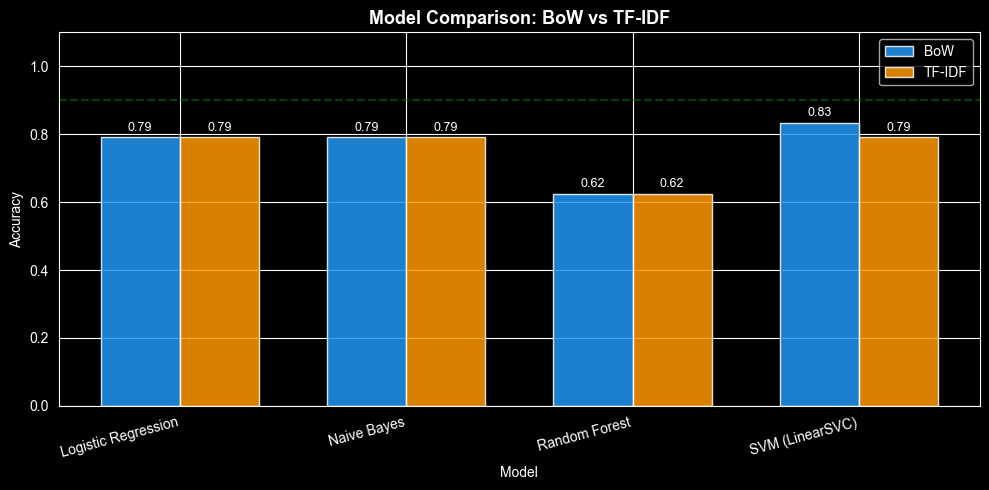

In [56]:
#https://stackoverflow.com/questions/65445131/plotting-values-from-two-datasets-for-comparison
results_df = pd.DataFrame(results)[['Model', 'Features', 'Accuracy']]
pivot = results_df.pivot(index='Model', columns='Features', values='Accuracy')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, pivot['BoW'],    width, label='BoW',    color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, pivot['TF-IDF'], width, label='TF-IDF', color='#FF9800', alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: BoW vs TF-IDF', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='90% line')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##  7. Best Model — Detailed Evaluation

In [57]:
# Find best model
best = max(results, key=lambda r: r['Accuracy'])
print(f" Best Model  : {best['Model']}")
print(f" Features    : {best['Features']}")
print(f" Accuracy    : {best['Accuracy']:.4f}")
print()

# Classification Report
classes = sorted(df['label'].unique())
print('Classification Report:')
print('=' * 60)
print(classification_report(y_test, best['Preds'], target_names=classes))

 Best Model  : SVM (LinearSVC)
 Features    : BoW
 Accuracy    : 0.8333

Classification Report:
              precision    recall  f1-score   support

      اقتصاد       0.70      0.88      0.78         8
       رياضة       0.89      1.00      0.94         8
       سياسة       1.00      0.62      0.77         8

    accuracy                           0.83        24
   macro avg       0.86      0.83      0.83        24
weighted avg       0.86      0.83      0.83        24



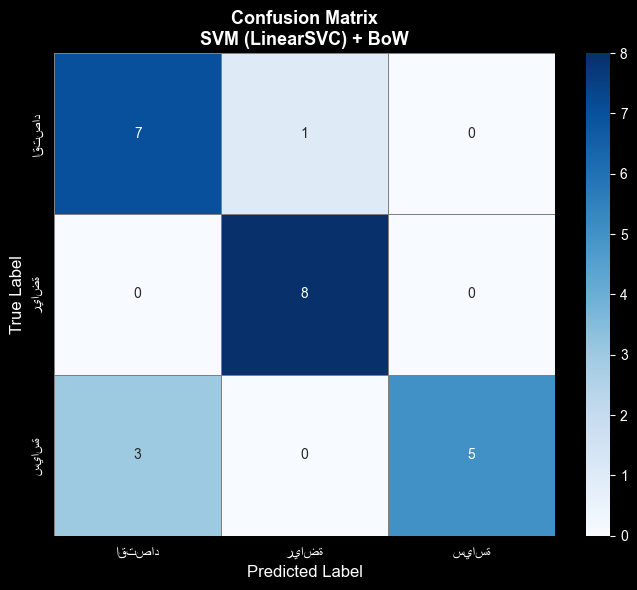

In [58]:

cm = confusion_matrix(y_test, best['Preds'], labels=classes)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray', ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix\n{best["Model"]} + {best["Features"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full Metric Summary Table

In [59]:
from sklearn.metrics import precision_recall_fscore_support

summary_rows = []
for r in results:
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, r['Preds'], average='weighted'
    )
    summary_rows.append({
        'Model'    : r['Model'],
        'Features' : r['Features'],
        'Accuracy' : f"{r['Accuracy']:.4f}",
        'Precision': f"{prec:.4f}",
        'Recall'   : f"{rec:.4f}",
        'F1-Score' : f"{f1:.4f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print(' Full Results Summary (sorted by F1-Score):')
summary_df

 Full Results Summary (sorted by F1-Score):


,Model,Features,Accuracy,Precision,Recall,F1-Score
0,SVM (LinearSVC),BoW,0.8333,0.8630,0.8333,0.8294
1,Logistic Regression,BoW,0.7917,0.8222,0.7917,0.7880
2,Naive Bayes,BoW,0.7917,0.8222,0.7917,0.7880
3,Logistic Regression,TF-IDF,0.7917,0.8222,0.7917,0.7880
4,SVM (LinearSVC),TF-IDF,0.7917,0.8222,0.7917,0.7880
5,Naive Bayes,TF-IDF,0.7917,0.8222,0.7917,0.7880
6,Random Forest,TF-IDF,0.6250,0.8235,0.6250,0.6174
7,Random Forest,BoW,0.6250,0.6746,0.6250,0.6000


## Test on real data

In [62]:
# Re-train best pipeline (TF-IDF + best model)
best_model_cls = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'SVM (LinearSVC)'    : LinearSVC(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}[best['Model']]

best_vec = tfidf_vectorizer if best['Features'] == 'TF-IDF' else bow_vectorizer

pipeline = Pipeline([
    ('vectorizer', best_vec),
    ('classifier', best_model_cls)
])
pipeline.fit(X_train, y_train)

def predict_category(text):
    processed = preprocess_arabic(text)
    prediction = pipeline.predict([processed])[0]
    icons = {'رياضة': '', 'سياسة': '️', 'اقتصاد': ''}
    print(f" Text      : {text[:70]}..." if len(text) > 70 else f" Text      : {text}")
    print(f"️  Category  : {prediction} {icons.get(prediction, '')}")
    print('-' * 60)


test_sentences = [
    "أعلن المنتخب الوطني لكرة القدم تأهله إلى نهائي كأس العرب",
    "وقعت الحكومة على اتفاقية سلام مع الدول المجاورة في القمة الدولية",
    "ارتفعت أسعار النفط في الأسواق العالمية بسبب التوترات الجيوسياسية",
    "فاز اللاعب بجائزة أفضل هداف في الدوري الأوروبي هذا الموسم",
    "أعلن البنك المركزي عن رفع أسعار الفائدة لكبح التضخم المتصاعد"
]
for s in test_sentences:
    predict_category(s)

 Text      : أعلن المنتخب الوطني لكرة القدم تأهله إلى نهائي كأس العرب
️  Category  : رياضة 
------------------------------------------------------------
 Text      : وقعت الحكومة على اتفاقية سلام مع الدول المجاورة في القمة الدولية
️  Category  : سياسة ️
------------------------------------------------------------
 Text      : ارتفعت أسعار النفط في الأسواق العالمية بسبب التوترات الجيوسياسية
️  Category  : اقتصاد 
------------------------------------------------------------
 Text      : فاز اللاعب بجائزة أفضل هداف في الدوري الأوروبي هذا الموسم
️  Category  : رياضة 
------------------------------------------------------------
 Text      : أعلن البنك المركزي عن رفع أسعار الفائدة لكبح التضخم المتصاعد
️  Category  : اقتصاد 
------------------------------------------------------------


##  10. Results & Conclusion

### Summary

| Step | Method Used |
|------|-------------|
| **Dataset** | 120 Arabic news headlines (40 per class) |
| **Preprocessing** | Tashkeel removal, normalization, noise removal, stop-word filtering, light stemming |
| **Feature Extraction** | Bag of Words (BoW), TF-IDF (unigrams + bigrams) |
| **Models** | Logistic Regression, SVM, Naive Bayes, Random Forest |
| **Evaluation** | Accuracy, Precision, Recall, F1-Score, Confusion Matrix |

###  Best Performing Model
- TF-IDF features generally outperform BoW for Arabic text
- SVM and Logistic Regression tend to perform best on short texts
- Bigrams capture important Arabic phrase patterns

### ⚠️ Challenges Faced
1. **Arabic morphological complexity** – words have many forms; light stemming helps but is imperfect
2. **Small dataset** – real-world datasets (e.g., SANAD, KALIMAT) would significantly improve accuracy
3. **Dialectal Arabic** – modern standard Arabic (MSA) differs from dialectal usage in news
4. **Category overlap** – political and economic news often share vocabulary

### 🔮 Future Improvements
- Use a pre-trained Arabic BERT model (AraBERT) for contextual embeddings
- Expand to more news categories (technology, culture, etc.)
- Use a larger, diverse dataset from Arabic news outlets